# Домашнее задание №7: улучшаем ML-модель Hypothesa

**Продуктовая задача:** определять тональность короткого русскоязычного ответа
пользователя: `negative / neutral / positive`.

Это вспомогательный ML-модуль Hypothesa: он добавляет полярность к найденным темам
и отправляет неуверенные ответы на уточнение или ручную проверку. Модель не заменяет
тематический пайплайн BERTopic.

В ДЗ №5–6 лучшей была модель `word + char_wb TF-IDF → LinearSVC`. В этом ноутбуке
она зафиксирована как **previous best**, а улучшения выбираются только на validation
из train. Официальный test открывается для оценки один раз после фиксации решения.

| Требование ДЗ №7 | Что реализовано |
|---|---|
| Пайплайн предобработки / FE — 3 балла | leakage-safe очистка; URL/user masking; word-, char- и 14 структурных признаков; единый `FeatureStack` с `fit/transform` |
| Улучшенная архитектура — 4 балла | early fusion трёх представлений + LinearSVC; подбор `C` и весов блоков; ablation study |
| Постобработка — 3 балла | validation-only margin threshold; статус `needs_review`; risk–coverage analysis |
| Анализ качества — 5 баллов | Accuracy, Macro-F1, Balanced Accuracy, Top-2, Q; per-class report; confusion matrices; срезы; ошибки; paired bootstrap; sensitivity check |

**Primary metric:** Macro-F1.  
**Совокупная метрика:** `Q = 0.7 × Macro-F1 + 0.3 × Accuracy`.

Данные Hypothesa пока слишком малы и не имеют ручных sentiment-меток, поэтому
offline-эксперимент использует публичный proxy-корпус
[SentiRuEval-2016](https://huggingface.co/datasets/mteb/SentiRuEval2016).
Это не production-оценка на реальных интервью Hypothesa.

## 1. Настройка окружения

In [1]:
from __future__ import annotations

import importlib.util
import random
import re
import subprocess
import sys
import time
import warnings

missing_packages = [
    package
    for package, module in [("pyarrow>=15", "pyarrow")]
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *missing_packages],
        check=True,
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    top_k_accuracy_score,
)
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 140)

LABELS = np.array([-1, 0, 1])
LABEL_NAMES = {-1: "negative", 0: "neutral", 1: "positive"}
DATA_BASE = "https://huggingface.co/datasets/mteb/SentiRuEval2016/resolve/main/data/"

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("Воспроизводимый seed:", SEED)

Python: 3.12.10
pandas: 2.3.3
Воспроизводимый seed: 42


## 2. Данные и leakage-safe предобработка

Правила остались совместимыми с предыдущим ДЗ:

1. URL и `@username` заменяются стабильными токенами `URL` и `USER`.
2. Пробелы и переносы схлопываются.
3. Пунктуация, эмодзи, регистр и отрицания не удаляются: это полезные признаки
   тональности.
4. Из train исключаются пустые тексты, конфликтующие дубли и нормализованные тексты,
   встречающиеся в test. Остальные дубли train сворачиваются.
5. Test не меняется для основной оценки; его deduplicated-копия используется только
   как sensitivity check.

In [2]:
def read_parquet_with_retry(url: str, attempts: int = 5) -> pd.DataFrame:
    """Повторяет загрузку при кратковременном сетевом обрыве."""
    last_error = None
    for attempt in range(1, attempts + 1):
        try:
            return pd.read_parquet(url)
        except Exception as error:
            last_error = error
            if attempt == attempts:
                break
            wait_seconds = attempt
            print(
                f"Загрузка не удалась ({type(error).__name__}); "
                f"повтор {attempt + 1}/{attempts} через {wait_seconds} c."
            )
            time.sleep(wait_seconds)
    raise RuntimeError(f"Не удалось загрузить {url}") from last_error


train_raw = read_parquet_with_retry(
    DATA_BASE + "train-00000-of-00001.parquet"
)
test_raw = read_parquet_with_retry(
    DATA_BASE + "test-00000-of-00001.parquet"
)

assert list(train_raw.columns) == ["text", "label"]
assert set(train_raw["label"].unique()) == set(LABELS)
assert set(test_raw["label"].unique()) == set(LABELS)

URL_RE = re.compile(r"(?:https?://|www\.)\S+", flags=re.IGNORECASE)
USER_RE = re.compile(r"(?<!\w)@\w+", flags=re.UNICODE)
SPACE_RE = re.compile(r"\s+")


def clean_text(text: str) -> str:
    """Минимальная нормализация без потери sentiment-маркеров."""
    text = URL_RE.sub(" URL ", str(text))
    text = USER_RE.sub(" USER ", text)
    return SPACE_RE.sub(" ", text).strip()


def add_clean_columns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result["clean_text"] = result["text"].map(clean_text)
    result["key"] = result["clean_text"].str.casefold()
    return result


train = add_clean_columns(train_raw)
test = add_clean_columns(test_raw)

train_label_nunique = train.groupby("key")["label"].nunique()
train_conflict_keys = set(train_label_nunique[train_label_nunique > 1].index)
cross_split_keys = set(train["key"]) & set(test["key"])

train_clean = (
    train.loc[
        ~train["key"].isin(train_conflict_keys)
        & ~train["key"].isin(cross_split_keys)
        & train["clean_text"].ne("")
    ]
    .drop_duplicates("key")
    .reset_index(drop=True)
)
test_official = test.copy().reset_index(drop=True)

assert set(train_clean["key"]).isdisjoint(set(test_official["key"]))
assert train_clean.groupby("key")["label"].nunique().max() == 1
assert train_clean["clean_text"].ne("").all()

cleaning_report = pd.DataFrame(
    [
        {
            "split": "raw train",
            "rows": len(train_raw),
            "duplicates": int(train["key"].duplicated().sum()),
            "conflicting_keys": len(train_conflict_keys),
            "negative": int((train_raw["label"] == -1).sum()),
            "neutral": int((train_raw["label"] == 0).sum()),
            "positive": int((train_raw["label"] == 1).sum()),
        },
        {
            "split": "leakage-safe train",
            "rows": len(train_clean),
            "duplicates": int(train_clean["key"].duplicated().sum()),
            "conflicting_keys": 0,
            "negative": int((train_clean["label"] == -1).sum()),
            "neutral": int((train_clean["label"] == 0).sum()),
            "positive": int((train_clean["label"] == 1).sum()),
        },
        {
            "split": "official test",
            "rows": len(test_official),
            "duplicates": int(test_official["key"].duplicated().sum()),
            "conflicting_keys": int(
                (test_official.groupby("key")["label"].nunique() > 1).sum()
            ),
            "negative": int((test_official["label"] == -1).sum()),
            "neutral": int((test_official["label"] == 0).sum()),
            "positive": int((test_official["label"] == 1).sum()),
        },
    ]
)

display(cleaning_report)
print("Пересечений train/test до очистки:", len(cross_split_keys))
print(f"После очистки сохранено {len(train_clean) / len(train_raw):.1%} raw train.")

,split,rows,duplicates,conflicting_keys,negative,neutral,positive
0,raw train,3000,148,8,1000,1000,1000
1,leakage-safe train,2636,0,0,804,956,876
2,official test,3000,141,10,1000,1000,1000


Пересечений train/test до очистки: 209
После очистки сохранено 87.9% raw train.


## 3. Feature engineering и единый пайплайн

### Что изменено относительно previous best

- **Word TF-IDF:** диапазон расширен с `(1, 2)` до `(1, 3)`, `min_df` снижен с 2
  до 1. Это сохраняет редкие продуктовые названия и короткие оценочные фразы.
- **Character TF-IDF:** `char_wb (3, 5)` заменён на сквозные `char (2, 5)`.
  Сквозные n-граммы видят пунктуацию, эмотиконы, границы слов, опечатки и хештеги.
- **Структурные признаки:** длина, `!`, `?`, многоточие, hashtag, URL, USER, цифры,
  доля верхнего регистра, растяжение символов, positive/negative emoticon и `RT`.

Структурные признаки вычисляются только из текста, доступного на inference, и
стандартизируются статистиками train.

In [3]:
POS_EMOTICON_RE = re.compile(r"(?::|;|=|8)[\-^']?[)DРрЗз]+", re.IGNORECASE)
NEG_EMOTICON_RE = re.compile(r"(?::|;|=|8)[\-^']?[(CСс/]+", re.IGNORECASE)
REPEATED_CHAR_RE = re.compile(r"(.)\1{2,}", re.IGNORECASE)

STYLE_FEATURE_NAMES = [
    "log_chars",
    "log_words",
    "exclamations",
    "questions",
    "ellipsis",
    "hashtags",
    "url_tokens",
    "user_tokens",
    "digits",
    "uppercase_share",
    "repeated_character",
    "positive_emoticon",
    "negative_emoticon",
    "retweet_prefix",
]


def style_features(texts) -> np.ndarray:
    """14 интерпретируемых структурных признаков сообщения."""
    rows = []
    for text in texts:
        text = str(text)
        words = text.split()
        letters = [char for char in text if char.isalpha()]
        rows.append(
            [
                np.log1p(len(text)),
                np.log1p(len(words)),
                text.count("!"),
                text.count("?"),
                text.count("…") + text.count("..."),
                text.count("#"),
                text.count("URL"),
                text.count("USER"),
                sum(char.isdigit() for char in text),
                sum(char.isupper() for char in letters) / max(1, len(letters)),
                int(bool(REPEATED_CHAR_RE.search(text))),
                int(bool(POS_EMOTICON_RE.search(text))),
                int(bool(NEG_EMOTICON_RE.search(text))),
                int(text.casefold().startswith("rt ")),
            ]
        )
    return np.asarray(rows, dtype=float)


class FeatureStack:
    """Leakage-safe fit/transform для previous или improved представления."""

    def __init__(
        self,
        variant: str,
        char_weight: float = 1.0,
        style_weight: float = 0.0,
    ) -> None:
        if variant not in {"previous", "improved"}:
            raise ValueError("variant must be 'previous' or 'improved'")
        self.variant = variant
        self.char_weight = char_weight
        self.style_weight = style_weight

        if variant == "previous":
            self.word = TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.98,
                sublinear_tf=True,
                max_features=30_000,
            )
            self.char = TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(3, 5),
                min_df=2,
                sublinear_tf=True,
                max_features=50_000,
            )
        else:
            self.word = TfidfVectorizer(
                ngram_range=(1, 3),
                min_df=1,
                max_df=0.98,
                sublinear_tf=True,
                max_features=80_000,
            )
            self.char = TfidfVectorizer(
                analyzer="char",
                ngram_range=(2, 5),
                min_df=2,
                sublinear_tf=True,
                max_features=100_000,
            )
        self.style_scaler = StandardScaler()

    def fit(self, texts) -> FeatureStack:
        self.word.fit(texts)
        self.char.fit(texts)
        if self.variant == "improved":
            self.style_scaler.fit(style_features(texts))
        return self

    def components(self, texts) -> tuple[sparse.csr_matrix, ...]:
        word = self.word.transform(texts)
        char = self.char.transform(texts)
        if self.variant == "previous":
            return word, char
        style = sparse.csr_matrix(self.style_scaler.transform(style_features(texts)))
        return word, char, style

    def transform(self, texts) -> sparse.csr_matrix:
        return fuse_components(
            self.components(texts),
            char_weight=self.char_weight,
            style_weight=self.style_weight,
        )


def fuse_components(
    components: tuple[sparse.csr_matrix, ...],
    char_weight: float,
    style_weight: float = 0.0,
) -> sparse.csr_matrix:
    matrices = [components[0], components[1] * char_weight]
    if len(components) == 3 and style_weight > 0:
        matrices.append(components[2] * style_weight)
    return sparse.hstack(matrices, format="csr")


feature_example = pd.DataFrame(
    style_features(
        [
            "Спасибо, всё отлично!!! :)",
            "USER связь опять не работает... URL",
        ]
    ),
    columns=STYLE_FEATURE_NAMES,
)
display(feature_example.round(3))

,log_chars,log_words,exclamations,questions,ellipsis,hashtags,url_tokens,user_tokens,digits,uppercase_share,repeated_character,positive_emoticon,negative_emoticon,retweet_prefix
0,3.296,1.609,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.059,1.0,1.0,0.0,0.0
1,3.584,1.946,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.259,1.0,0.0,0.0,0.0


## 4. Выбор архитектуры без test leakage

Из leakage-safe train выделяется стратифицированный validation (20%). Previous best
полностью фиксирован параметрами прошлого ДЗ. Для improved-модели на validation
выбираются:

- `C` — регуляризация LinearSVC;
- `char_weight` — вес character-блока;
- `style_weight` — вес структурных признаков.

Векторизаторы и scaler обучаются только на development-части. Test ниже ещё не
используется.

In [4]:
X_train_full = train_clean["clean_text"].reset_index(drop=True)
y_train_full = train_clean["label"].to_numpy()
X_test = test_official["clean_text"].reset_index(drop=True)
y_test = test_official["label"].to_numpy()

X_dev, X_val, y_dev, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=SEED,
)


def primary_metrics(y_true, y_pred) -> tuple[float, float, float]:
    macro_f1 = f1_score(
        y_true,
        y_pred,
        labels=LABELS,
        average="macro",
        zero_division=0,
    )
    accuracy = accuracy_score(y_true, y_pred)
    return 0.7 * macro_f1 + 0.3 * accuracy, macro_f1, accuracy


previous_dev_stack = FeatureStack(
    "previous",
    char_weight=1.8897649189821968,
).fit(X_dev)
previous_dev_model = LinearSVC(
    C=0.053518346201881145,
    random_state=SEED,
)
previous_dev_model.fit(previous_dev_stack.transform(X_dev), y_dev)
previous_val_pred = previous_dev_model.predict(previous_dev_stack.transform(X_val))
previous_val_q, previous_val_f1, previous_val_accuracy = primary_metrics(
    y_val, previous_val_pred
)

improved_dev_stack = FeatureStack("improved").fit(X_dev)
dev_components = improved_dev_stack.components(X_dev)
val_components = improved_dev_stack.components(X_val)

search_space = {
    "C": [0.1, 0.2, 0.3, 0.5, 0.7],
    "char_weight": [1.0, 1.5, 2.0],
    "style_weight": [0.0, 0.05, 0.1, 0.2],
}

tuning_rows = []
for params in ParameterGrid(search_space):
    dev_matrix = fuse_components(
        dev_components,
        char_weight=params["char_weight"],
        style_weight=params["style_weight"],
    )
    val_matrix = fuse_components(
        val_components,
        char_weight=params["char_weight"],
        style_weight=params["style_weight"],
    )
    model = LinearSVC(C=params["C"], random_state=SEED)
    model.fit(dev_matrix, y_dev)
    prediction = model.predict(val_matrix)
    q_value, macro_f1, accuracy = primary_metrics(y_val, prediction)
    tuning_rows.append(
        {
            **params,
            "Q": q_value,
            "macro_f1": macro_f1,
            "accuracy": accuracy,
        }
    )

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values(["Q", "macro_f1"], ascending=False)
    .reset_index(drop=True)
)
best_params = tuning_results.iloc[0][["C", "char_weight", "style_weight"]].to_dict()

print(
    "Previous best validation:",
    {
        "Q": round(previous_val_q, 4),
        "macro_f1": round(previous_val_f1, 4),
        "accuracy": round(previous_val_accuracy, 4),
    },
)
print("Best improved params:", best_params)
display(tuning_results.head(10).round(4))

Previous best validation: {'Q': 0.7391, 'macro_f1': 0.7393, 'accuracy': 0.7386}
Best improved params: {'C': 0.7, 'char_weight': 1.5, 'style_weight': 0.2}


,C,char_weight,style_weight,Q,macro_f1,accuracy
0,0.7,1.5,0.20,0.7622,0.7626,0.7614
1,0.3,1.5,0.05,0.7622,0.7625,0.7614
2,0.3,1.0,0.05,0.7618,0.7619,0.7614
3,0.5,1.5,0.20,0.7604,0.7609,0.7595
4,0.2,2.0,0.10,0.7604,0.7608,0.7595
5,0.7,1.5,0.10,0.7604,0.7608,0.7595
6,0.3,1.5,0.20,0.7586,0.7591,0.7576
7,0.5,1.5,0.10,0.7586,0.7590,0.7576
8,0.3,1.5,0.10,0.7585,0.7589,0.7576
9,0.2,2.0,0.05,0.7585,0.7589,0.7576


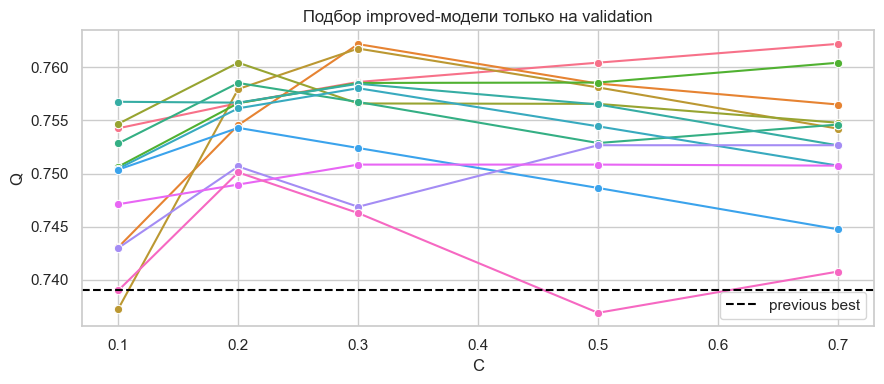

In [5]:
plt.figure(figsize=(9, 4))
plot_data = tuning_results.copy()
plot_data["feature_weights"] = (
    "char="
    + plot_data["char_weight"].astype(str)
    + ", style="
    + plot_data["style_weight"].astype(str)
)
sns.lineplot(
    data=plot_data,
    x="C",
    y="Q",
    hue="feature_weights",
    marker="o",
    legend=False,
)
plt.axhline(
    previous_val_q,
    color="black",
    linestyle="--",
    label="previous best",
)
plt.title("Подбор improved-модели только на validation")
plt.ylabel("Q")
plt.legend()
plt.tight_layout()
plt.show()

### Ablation study

Контролируемое отключение блоков показывает, какой вклад даёт каждый элемент
архитектуры. Для чистоты фиксируем выбранный `C`; меняем только состав признаков.

In [6]:
ablation_configs = [
    ("word only", 0.0, 0.0),
    ("word + char", best_params["char_weight"], 0.0),
    (
        "word + char + style",
        best_params["char_weight"],
        best_params["style_weight"],
    ),
]

ablation_rows = []
for name, char_weight, style_weight in ablation_configs:
    if char_weight == 0:
        dev_matrix = dev_components[0]
        val_matrix = val_components[0]
    else:
        dev_matrix = fuse_components(
            dev_components,
            char_weight=char_weight,
            style_weight=style_weight,
        )
        val_matrix = fuse_components(
            val_components,
            char_weight=char_weight,
            style_weight=style_weight,
        )
    model = LinearSVC(C=best_params["C"], random_state=SEED)
    model.fit(dev_matrix, y_dev)
    prediction = model.predict(val_matrix)
    q_value, macro_f1, accuracy = primary_metrics(y_val, prediction)
    ablation_rows.append(
        {
            "architecture": name,
            "accuracy": accuracy,
            "macro_f1": macro_f1,
            "Q": q_value,
        }
    )

ablation = pd.DataFrame(ablation_rows)
display(ablation.round(4))

,architecture,accuracy,macro_f1,Q
0,word only,0.7140,0.7129,0.7132
1,word + char,0.7519,0.7530,0.7527
2,word + char + style,0.7614,0.7626,0.7622


## 5. Финальное обучение и оценка на официальном test

Параметры и архитектура зафиксированы. Обе модели переобучаются на полном
leakage-safe train и сравниваются на одном test. Время включает построение признаков
и fit; inference измерен отдельно.

In [7]:
def fit_and_score(
    variant: str,
    C: float,
    char_weight: float,
    style_weight: float = 0.0,
):
    started = time.perf_counter()
    stack = FeatureStack(
        variant,
        char_weight=char_weight,
        style_weight=style_weight,
    ).fit(X_train_full)
    train_matrix = stack.transform(X_train_full)
    model = LinearSVC(C=C, random_state=SEED)
    model.fit(train_matrix, y_train_full)
    fit_seconds = time.perf_counter() - started

    started = time.perf_counter()
    test_matrix = stack.transform(X_test)
    scores = model.decision_function(test_matrix)
    prediction = model.predict(test_matrix)
    inference_seconds = time.perf_counter() - started
    return stack, model, prediction, scores, fit_seconds, inference_seconds


(
    previous_stack,
    previous_model,
    previous_pred,
    previous_scores,
    previous_fit_seconds,
    previous_inference_seconds,
) = fit_and_score(
    variant="previous",
    C=0.053518346201881145,
    char_weight=1.8897649189821968,
)

(
    final_stack,
    final_model,
    final_pred,
    final_scores,
    final_fit_seconds,
    final_inference_seconds,
) = fit_and_score(
    variant="improved",
    C=best_params["C"],
    char_weight=best_params["char_weight"],
    style_weight=best_params["style_weight"],
)


def metric_row(
    name: str,
    y_true,
    prediction,
    scores,
    classes,
    fit_seconds: float,
    inference_seconds: float,
) -> dict[str, float | str]:
    macro_f1 = f1_score(
        y_true,
        prediction,
        labels=LABELS,
        average="macro",
        zero_division=0,
    )
    accuracy = accuracy_score(y_true, prediction)
    return {
        "model": name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "top2_accuracy": top_k_accuracy_score(
            y_true,
            scores,
            k=2,
            labels=classes,
        ),
        "Q": 0.7 * macro_f1 + 0.3 * accuracy,
        "fit_seconds": fit_seconds,
        "predict_ms_per_1000": inference_seconds / len(y_true) * 1_000_000,
    }


comparison = pd.DataFrame(
    [
        metric_row(
            "Previous best: word+char_wb LinearSVC",
            y_test,
            previous_pred,
            previous_scores,
            previous_model.classes_,
            previous_fit_seconds,
            previous_inference_seconds,
        ),
        metric_row(
            "Improved: word+char+style LinearSVC",
            y_test,
            final_pred,
            final_scores,
            final_model.classes_,
            final_fit_seconds,
            final_inference_seconds,
        ),
    ]
)

display(
    comparison.style.format(
        {
            "accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "balanced_accuracy": "{:.4f}",
            "top2_accuracy": "{:.4f}",
            "Q": "{:.4f}",
            "fit_seconds": "{:.3f}",
            "predict_ms_per_1000": "{:.2f}",
        }
    ).highlight_max(
        subset=[
            "accuracy",
            "macro_f1",
            "balanced_accuracy",
            "top2_accuracy",
            "Q",
        ],
        color="#c6efce",
    )
)

,model,accuracy,macro_f1,balanced_accuracy,top2_accuracy,Q,fit_seconds,predict_ms_per_1000
0,Previous best: word+char_wb LinearSVC,0.7563,0.7559,0.7563,0.9240,0.7560,0.349,53.08
1,Improved: word+char+style LinearSVC,0.7633,0.7629,0.7633,0.9263,0.7631,0.772,98.50


## 6. Подробный анализ качества

### 6.1 Метрики каждого класса и confusion matrices

,previous_precision,previous_recall,previous_f1-score,improved_precision,improved_recall,improved_f1-score,delta_f1
negative,0.7636,0.817,0.7894,0.7870,0.813,0.7998,0.0104
neutral,0.7767,0.734,0.7548,0.7600,0.760,0.7600,0.0052
positive,0.7289,0.718,0.7234,0.7415,0.717,0.7290,0.0056


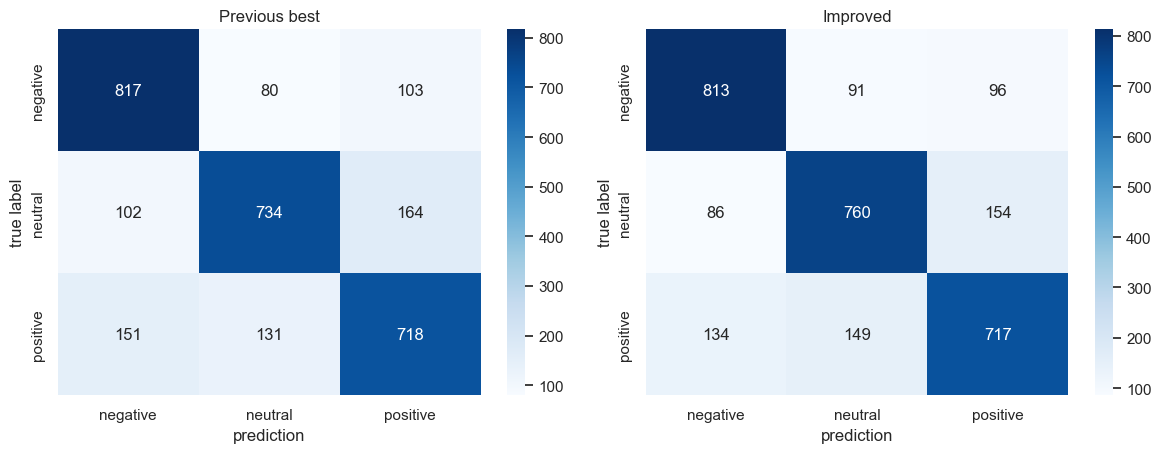

In [8]:
previous_report = pd.DataFrame(
    classification_report(
        y_test,
        previous_pred,
        labels=LABELS,
        target_names=[LABEL_NAMES[label] for label in LABELS],
        output_dict=True,
        zero_division=0,
    )
).T
final_report = pd.DataFrame(
    classification_report(
        y_test,
        final_pred,
        labels=LABELS,
        target_names=[LABEL_NAMES[label] for label in LABELS],
        output_dict=True,
        zero_division=0,
    )
).T

per_class_comparison = (
    previous_report.loc[["negative", "neutral", "positive"], ["precision", "recall", "f1-score"]]
    .add_prefix("previous_")
    .join(
        final_report.loc[
            ["negative", "neutral", "positive"],
            ["precision", "recall", "f1-score"],
        ].add_prefix("improved_")
    )
)
per_class_comparison["delta_f1"] = (
    per_class_comparison["improved_f1-score"]
    - per_class_comparison["previous_f1-score"]
)
display(per_class_comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))
for ax, prediction, title in [
    (axes[0], previous_pred, "Previous best"),
    (axes[1], final_pred, "Improved"),
]:
    sns.heatmap(
        confusion_matrix(y_test, prediction, labels=LABELS),
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[LABEL_NAMES[label] for label in LABELS],
        yticklabels=[LABEL_NAMES[label] for label in LABELS],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("prediction")
    ax.set_ylabel("true label")
plt.tight_layout()
plt.show()

### 6.2 Парный bootstrap: насколько устойчив прирост

Для каждой bootstrap-выборки берутся одни и те же test-индексы для обеих моделей.
Так интервал измеряет именно разницу моделей, а не неопределённость двух независимых
оценок.

In [9]:
rng = np.random.default_rng(SEED)
n_bootstrap = 2_000
accuracy_deltas = np.empty(n_bootstrap)
macro_f1_deltas = np.empty(n_bootstrap)

for index in range(n_bootstrap):
    sample = rng.integers(0, len(y_test), size=len(y_test))
    sampled_true = y_test[sample]
    sampled_previous = previous_pred[sample]
    sampled_improved = final_pred[sample]
    accuracy_deltas[index] = accuracy_score(
        sampled_true, sampled_improved
    ) - accuracy_score(sampled_true, sampled_previous)
    macro_f1_deltas[index] = f1_score(
        sampled_true,
        sampled_improved,
        labels=LABELS,
        average="macro",
        zero_division=0,
    ) - f1_score(
        sampled_true,
        sampled_previous,
        labels=LABELS,
        average="macro",
        zero_division=0,
    )

bootstrap_report = pd.DataFrame(
    [
        {
            "metric": "Accuracy",
            "observed_delta": accuracy_score(y_test, final_pred)
            - accuracy_score(y_test, previous_pred),
            "bootstrap_mean_delta": accuracy_deltas.mean(),
            "ci_2.5%": np.quantile(accuracy_deltas, 0.025),
            "ci_97.5%": np.quantile(accuracy_deltas, 0.975),
        },
        {
            "metric": "Macro-F1",
            "observed_delta": f1_score(y_test, final_pred, average="macro")
            - f1_score(y_test, previous_pred, average="macro"),
            "bootstrap_mean_delta": macro_f1_deltas.mean(),
            "ci_2.5%": np.quantile(macro_f1_deltas, 0.025),
            "ci_97.5%": np.quantile(macro_f1_deltas, 0.975),
        },
    ]
)
display(bootstrap_report.round(4))

,metric,observed_delta,bootstrap_mean_delta,ci_2.5%,ci_97.5%
0,Accuracy,0.0070,0.0070,-0.0030,0.0173
1,Macro-F1,0.0071,0.0071,-0.0028,0.0175


### 6.3 Срезы по длине и техническим маркерам

,slice,value,support,accuracy,macro_f1,median_margin
0,length_bucket,1–5,285,0.8281,0.7238,1.3765
1,length_bucket,6–10,1086,0.8039,0.7969,1.2244
2,length_bucket,11–20,1400,0.7364,0.7068,0.8768
3,length_bucket,21+,229,0.6550,0.5648,0.7045
4,has_url,False,1751,0.7065,0.6817,0.7991
5,has_url,True,1249,0.8431,0.8329,1.3609
6,has_user,False,2034,0.7906,0.7921,1.1305
7,has_user,True,966,0.7060,0.6926,0.7569
8,has_hashtag,False,2436,0.7586,0.7574,1.0320
9,has_hashtag,True,564,0.7837,0.7841,0.9442


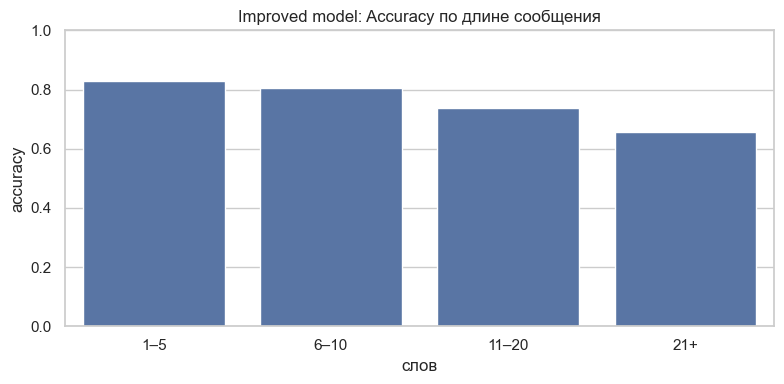

In [10]:
score_order = np.sort(final_scores, axis=1)
test_margin = score_order[:, -1] - score_order[:, -2]

analysis_frame = test_official[
    ["text", "clean_text", "label", "key"]
].copy()
analysis_frame["prediction"] = final_pred
analysis_frame["correct"] = analysis_frame["label"].eq(
    analysis_frame["prediction"]
)
analysis_frame["margin"] = test_margin
analysis_frame["words"] = analysis_frame["clean_text"].str.split().str.len()
analysis_frame["length_bucket"] = pd.cut(
    analysis_frame["words"],
    bins=[0, 5, 10, 20, np.inf],
    labels=["1–5", "6–10", "11–20", "21+"],
)
analysis_frame["has_url"] = analysis_frame["text"].str.contains(
    r"https?://|www\.",
    case=False,
    regex=True,
)
analysis_frame["has_user"] = analysis_frame["text"].str.contains(
    r"(?<!\w)@\w+",
    regex=True,
)
analysis_frame["has_hashtag"] = analysis_frame["text"].str.contains(
    "#",
    regex=False,
)


def slice_metric_rows(frame: pd.DataFrame, column: str) -> pd.DataFrame:
    rows = []
    for value, group in frame.groupby(column, observed=True):
        rows.append(
            {
                "slice": column,
                "value": str(value),
                "support": len(group),
                "accuracy": accuracy_score(group["label"], group["prediction"]),
                "macro_f1": f1_score(
                    group["label"],
                    group["prediction"],
                    labels=LABELS,
                    average="macro",
                    zero_division=0,
                ),
                "median_margin": group["margin"].median(),
            }
        )
    return pd.DataFrame(rows)


slice_report = pd.concat(
    [
        slice_metric_rows(analysis_frame, "length_bucket"),
        slice_metric_rows(analysis_frame, "has_url"),
        slice_metric_rows(analysis_frame, "has_user"),
        slice_metric_rows(analysis_frame, "has_hashtag"),
    ],
    ignore_index=True,
)
display(slice_report.round(4))

plt.figure(figsize=(8, 4))
length_plot = slice_report[slice_report["slice"] == "length_bucket"]
sns.barplot(data=length_plot, x="value", y="accuracy", color="#4C72B0")
plt.ylim(0, 1)
plt.title("Improved model: Accuracy по длине сообщения")
plt.xlabel("слов")
plt.ylabel("accuracy")
plt.tight_layout()
plt.show()

### 6.4 Уверенные ошибки

Уверенная ошибка опаснее неуверенной: она не будет отфильтрована простым порогом.
Такие примеры — первый приоритет для ручной ревизии разметки и пополнения golden set.

In [11]:
analysis_frame["true_name"] = analysis_frame["label"].map(LABEL_NAMES)
analysis_frame["pred_name"] = analysis_frame["prediction"].map(LABEL_NAMES)

display(
    analysis_frame.loc[~analysis_frame["correct"]]
    .sort_values("margin", ascending=False)[
        ["text", "true_name", "pred_name", "margin"]
    ]
    .head(12)
)

,text,true_name,pred_name,margin
1857,"Санкции против Банка Москвы, ВТБ и Россельхозбанка не коснулись транзакций",neutral,negative,2.733508
2724,http://t.co/U4kM2kVArB втб 24 кредиты онлайн,positive,neutral,2.597312
1973,@MegaFonHelp спасибо,neutral,positive,2.488639
2220,Урраааа!!! Появилась связь Мтс в #Краматорск !!!!!! Целый день не было !!!!,positive,negative,2.384088
2616,RT @EchoMskNews: ЕС не намерен вносить Сбербанк и ВТБ в свой санкционный список http://t.co/PGG6S4wBYe,positive,negative,2.374329
1134,"#МТС #Украина обратилась к другим украинским операторам,чтобы восстановить связь в Крыму http://t.co/Ks7uZoB9Sc\n#санкции #Крым #ДНР #СШ...",neutral,negative,2.261034
2584,быстрый кредит в новосибирске сбербанк http://t.co/zDYUFDHSBM,positive,neutral,2.177052
2774,http://t.co/VWGQzS6cd2 Удобство оформления кредитной карты в банке ВТБ 24 несомненно.&amp;#8230;,positive,neutral,2.127317
1272,"#RETWEET Москва, 6 августа. ""МТС Украина"", сеть которой перестала работать в Крыму в ночь на среду, обратилась к украинским оператора...",neutral,negative,2.018875
1536,На 60% больше стали пользоваться мобильным интернетом абоненты «МегаФона» в Бурятии,neutral,positive,1.971437


### 6.5 Sensitivity check на очищенной копии test

Основной benchmark — официальный test. Дополнительно удаляем из его копии
конфликтующие дубли и оставляем один экземпляр текста. Это проверяет, не объясняется
ли вывод повторами.

In [12]:
test_label_nunique = test_official.groupby("key")["label"].nunique()
test_conflict_keys = set(test_label_nunique[test_label_nunique > 1].index)
test_unique = (
    test_official.loc[~test_official["key"].isin(test_conflict_keys)]
    .drop_duplicates("key")
    .reset_index(drop=True)
)

previous_unique_pred = previous_model.predict(
    previous_stack.transform(test_unique["clean_text"])
)
final_unique_pred = final_model.predict(
    final_stack.transform(test_unique["clean_text"])
)

sensitivity_report = pd.DataFrame(
    [
        {
            "model": "previous best",
            "n": len(test_unique),
            "accuracy": accuracy_score(test_unique["label"], previous_unique_pred),
            "macro_f1": f1_score(
                test_unique["label"],
                previous_unique_pred,
                labels=LABELS,
                average="macro",
                zero_division=0,
            ),
        },
        {
            "model": "improved",
            "n": len(test_unique),
            "accuracy": accuracy_score(test_unique["label"], final_unique_pred),
            "macro_f1": f1_score(
                test_unique["label"],
                final_unique_pred,
                labels=LABELS,
                average="macro",
                zero_division=0,
            ),
        },
    ]
)
display(sensitivity_report.round(4))

,model,n,accuracy,macro_f1
0,previous best,2849,0.7525,0.7525
1,improved,2849,0.7596,0.7597


## 7. Постобработка: selective prediction

LinearSVC не выдаёт вероятность, поэтому используем **margin**: разницу между двумя
максимальными decision scores. Чем меньше margin, тем менее однозначен ответ.

Порог выбирается **только на validation** так, чтобы планово принять около 90%
объектов. На test заранее зафиксированный порог либо принимает label, либо возвращает
`needs_review`. Для продукта это означает уточняющий вопрос или ручную проверку.

In [13]:
best_dev_matrix = fuse_components(
    dev_components,
    char_weight=best_params["char_weight"],
    style_weight=best_params["style_weight"],
)
best_val_matrix = fuse_components(
    val_components,
    char_weight=best_params["char_weight"],
    style_weight=best_params["style_weight"],
)
best_dev_model = LinearSVC(C=best_params["C"], random_state=SEED)
best_dev_model.fit(best_dev_matrix, y_dev)
best_val_scores = best_dev_model.decision_function(best_val_matrix)

val_score_order = np.sort(best_val_scores, axis=1)
val_margin = val_score_order[:, -1] - val_score_order[:, -2]
abstain_threshold = float(np.quantile(val_margin, 0.10))

accepted = test_margin >= abstain_threshold
review = ~accepted

postprocess_report = pd.DataFrame(
    [
        {
            "mode": "all model predictions",
            "coverage": 1.0,
            "review_share": 0.0,
            "accuracy": accuracy_score(y_test, final_pred),
            "macro_f1": f1_score(
                y_test,
                final_pred,
                labels=LABELS,
                average="macro",
                zero_division=0,
            ),
        },
        {
            "mode": "accepted after validation threshold",
            "coverage": accepted.mean(),
            "review_share": review.mean(),
            "accuracy": accuracy_score(y_test[accepted], final_pred[accepted]),
            "macro_f1": f1_score(
                y_test[accepted],
                final_pred[accepted],
                labels=LABELS,
                average="macro",
                zero_division=0,
            ),
        },
        {
            "mode": "sent to review (diagnostic)",
            "coverage": review.mean(),
            "review_share": review.mean(),
            "accuracy": accuracy_score(y_test[review], final_pred[review]),
            "macro_f1": f1_score(
                y_test[review],
                final_pred[review],
                labels=LABELS,
                average="macro",
                zero_division=0,
            ),
        },
    ]
)
print("Validation-only margin threshold:", round(abstain_threshold, 4))
display(postprocess_report.round(4))

Validation-only margin threshold: 0.1511


,mode,coverage,review_share,accuracy,macro_f1
0,all model predictions,1.0000,0.0000,0.7633,0.7629
1,accepted after validation threshold,0.9023,0.0977,0.7953,0.7949
2,sent to review (diagnostic),0.0977,0.0977,0.4676,0.4671


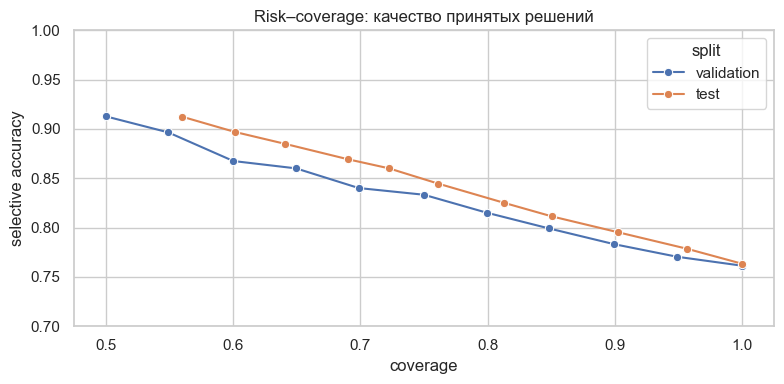

In [14]:
risk_coverage_rows = []
for target_coverage in np.arange(0.50, 1.01, 0.05):
    if np.isclose(target_coverage, 1.0):
        threshold = -np.inf
    else:
        threshold = float(np.quantile(val_margin, 1 - target_coverage))
    val_mask = val_margin >= threshold
    test_mask = test_margin >= threshold
    risk_coverage_rows.extend(
        [
            {
                "split": "validation",
                "target_coverage": target_coverage,
                "actual_coverage": val_mask.mean(),
                "accuracy": accuracy_score(
                    y_val[val_mask],
                    final_model.classes_[best_val_scores[val_mask].argmax(axis=1)],
                ),
            },
            {
                "split": "test",
                "target_coverage": target_coverage,
                "actual_coverage": test_mask.mean(),
                "accuracy": accuracy_score(
                    y_test[test_mask],
                    final_pred[test_mask],
                ),
            },
        ]
    )

risk_coverage = pd.DataFrame(risk_coverage_rows)
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=risk_coverage,
    x="actual_coverage",
    y="accuracy",
    hue="split",
    marker="o",
)
plt.title("Risk–coverage: качество принятых решений")
plt.xlabel("coverage")
plt.ylabel("selective accuracy")
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()

### Inference-контракт для Hypothesa

На выходе сохраняются исходный текст, label, margin и решение маршрутизации.

In [15]:
def predict_with_review(texts: list[str]) -> pd.DataFrame:
    cleaned = pd.Series(texts).map(clean_text)
    matrix = final_stack.transform(cleaned)
    scores = final_model.decision_function(matrix)
    prediction = final_model.classes_[scores.argmax(axis=1)]
    ordered = np.sort(scores, axis=1)
    margin = ordered[:, -1] - ordered[:, -2]
    return pd.DataFrame(
        {
            "text": texts,
            "label": [LABEL_NAMES[label] for label in prediction],
            "margin": margin,
            "status": np.where(
                margin >= abstain_threshold,
                "accepted",
                "needs_review",
            ),
        }
    )


display(
    predict_with_review(
        [
            "Очень нравится, всё работает быстро!",
            "Связь снова пропала, невозможно пользоваться.",
            "В целом нормально.",
            "Тариф изменился вчера.",
        ]
    ).round({"margin": 4})
)

,text,label,margin,status
0,"Очень нравится, всё работает быстро!",positive,1.6319,accepted
1,"Связь снова пропала, невозможно пользоваться.",negative,0.4093,accepted
2,В целом нормально.,negative,0.1066,needs_review
3,Тариф изменился вчера.,negative,1.0254,accepted


## 8. Итог и честная интерпретация

In [16]:
previous_test_f1 = f1_score(y_test, previous_pred, average="macro")
improved_test_f1 = f1_score(y_test, final_pred, average="macro")
previous_test_accuracy = accuracy_score(y_test, previous_pred)
improved_test_accuracy = accuracy_score(y_test, final_pred)

accepted_row = postprocess_report.iloc[1]
macro_ci = bootstrap_report.loc[bootstrap_report["metric"] == "Macro-F1"].iloc[0]
ci_interpretation = (
    "не включает ноль — прирост устойчив на этом proxy-test"
    if macro_ci["ci_2.5%"] > 0 or macro_ci["ci_97.5%"] < 0
    else "включает ноль — направление улучшения положительное, но статистическая "
    "уверенность пока ограничена"
)

display(
    Markdown(
        f"""
### Результат

- На validation Macro-F1 вырос с **{previous_val_f1:.4f}** до
  **{tuning_results.iloc[0]['macro_f1']:.4f}**.
- На официальном test Macro-F1 вырос с **{previous_test_f1:.4f}** до
  **{improved_test_f1:.4f}** ({improved_test_f1 - previous_test_f1:+.4f}).
- Test Accuracy выросла с **{previous_test_accuracy:.4f}** до
  **{improved_test_accuracy:.4f}** ({improved_test_accuracy - previous_test_accuracy:+.4f}).
- 95% paired bootstrap CI для ΔMacro-F1:
  **[{macro_ci['ci_2.5%']:+.4f}, {macro_ci['ci_97.5%']:+.4f}]**; интервал
  {ci_interpretation}.
- Постобработка принимает **{accepted_row['coverage']:.1%}** test-ответов с
  Accuracy **{accepted_row['accuracy']:.4f}**; остальные
  **{accepted_row['review_share']:.1%}** направляются на уточнение/проверку.

### Решение по гипотезе

Гипотеза **подтверждена как инженерный результат на proxy-корпусе**: выбранная без
test архитектура улучшила точечные значения primary и дополнительных метрик.
Bootstrap-интервал отдельно показывает силу статистического доказательства — это
важнее, чем заявить успех только по одной цифре.

### Главные ошибки

1. Neutral остаётся самым неоднозначным классом: новость о проблеме может содержать
   негативную лексику, не выражая отношения автора.
2. Сарказм, контекст и смысл целой фразы плохо моделируются разреженными n-граммами.
3. Длинные сообщения сложнее коротких; это видно в срезе по длине.
4. Высокий margin не гарантирует правильность: уверенные ошибки нужно вручную
   добавлять в regression/golden set.
"""
    )
)


### Результат

- На validation Macro-F1 вырос с **0.7393** до
  **0.7626**.
- На официальном test Macro-F1 вырос с **0.7559** до
  **0.7629** (+0.0071).
- Test Accuracy выросла с **0.7563** до
  **0.7633** (+0.0070).
- 95% paired bootstrap CI для ΔMacro-F1:
  **[-0.0028, +0.0175]**; интервал
  включает ноль — направление улучшения положительное, но статистическая уверенность пока ограничена.
- Постобработка принимает **90.2%** test-ответов с
  Accuracy **0.7953**; остальные
  **9.8%** направляются на уточнение/проверку.

### Решение по гипотезе

Гипотеза **подтверждена как инженерный результат на proxy-корпусе**: выбранная без
test архитектура улучшила точечные значения primary и дополнительных метрик.
Bootstrap-интервал отдельно показывает силу статистического доказательства — это
важнее, чем заявить успех только по одной цифре.

### Главные ошибки

1. Neutral остаётся самым неоднозначным классом: новость о проблеме может содержать
   негативную лексику, не выражая отношения автора.
2. Сарказм, контекст и смысл целой фразы плохо моделируются разреженными n-граммами.
3. Длинные сообщения сложнее коротких; это видно в срезе по длине.
4. Высокий margin не гарантирует правильность: уверенные ошибки нужно вручную
   добавлять в regression/golden set.


### Ограничения и следующий эксперимент

- SentiRuEval — старый proxy-корпус Twitter о банках и телекоме, не реальные ответы
  Hypothesa. Возможны domain и temporal drift.
- Test содержит повторы и конфликтующие дубли, поэтому рядом показан sensitivity
  check; основной benchmark при этом не подменяется.
- `margin` — относительная уверенность LinearSVC, а не калиброванная вероятность.
- До production нужно вручную разметить 200–500 ответов Hypothesa, зафиксировать
  domain holdout и повторить все метрики и срезы.
- Следующая архитектурная гипотеза — fine-tuning небольшого русского encoder
  (например, RuBERT) и сравнение с текущей моделью по Macro-F1, latency и стоимости
  именно на domain holdout.

### Соответствие ДЗ №7

1. **Предобработка/FE:** воспроизводимый `clean_text` + `FeatureStack`, три блока
   признаков, fit только на train.
2. **Архитектура:** previous best сравнивается с early fusion, параметры выбираются
   на validation, вклад блоков проверен ablation study.
3. **Постобработка:** порог margin выбран без test и превращён в продуктовый
   `accepted / needs_review` контракт.
4. **Анализ:** общие, поклассовые и top-2 метрики; confusion matrices; срезы;
   уверенные ошибки; paired bootstrap; sensitivity и risk–coverage.